DESCRIPTIVE STATISTICS

Shooting Factor
  Max      : 8.4000
  Min      : -7.3000
  Mean     : 0.0004
  Median   : -0.0500
  Variance : 7.6052
  Std Dev  : 2.7578

Crashing Factor
  Max      : 107.3000
  Min      : 91.1000
  Mean     : 99.9735
  Median   : 100.1000
  Variance : 7.3773
  Std Dev  : 2.7161

Protecting Factor
  Max      : 3.8000
  Min      : -4.1000
  Mean     : -0.0015
  Median   : -0.1000
  Variance : 2.1077
  Std Dev  : 1.4518

Attacking Factor
  Max      : 8.3203
  Min      : -8.5576
  Mean     : -0.0086
  Median   : -0.0194
  Variance : 8.8031
  Std Dev  : 2.9670


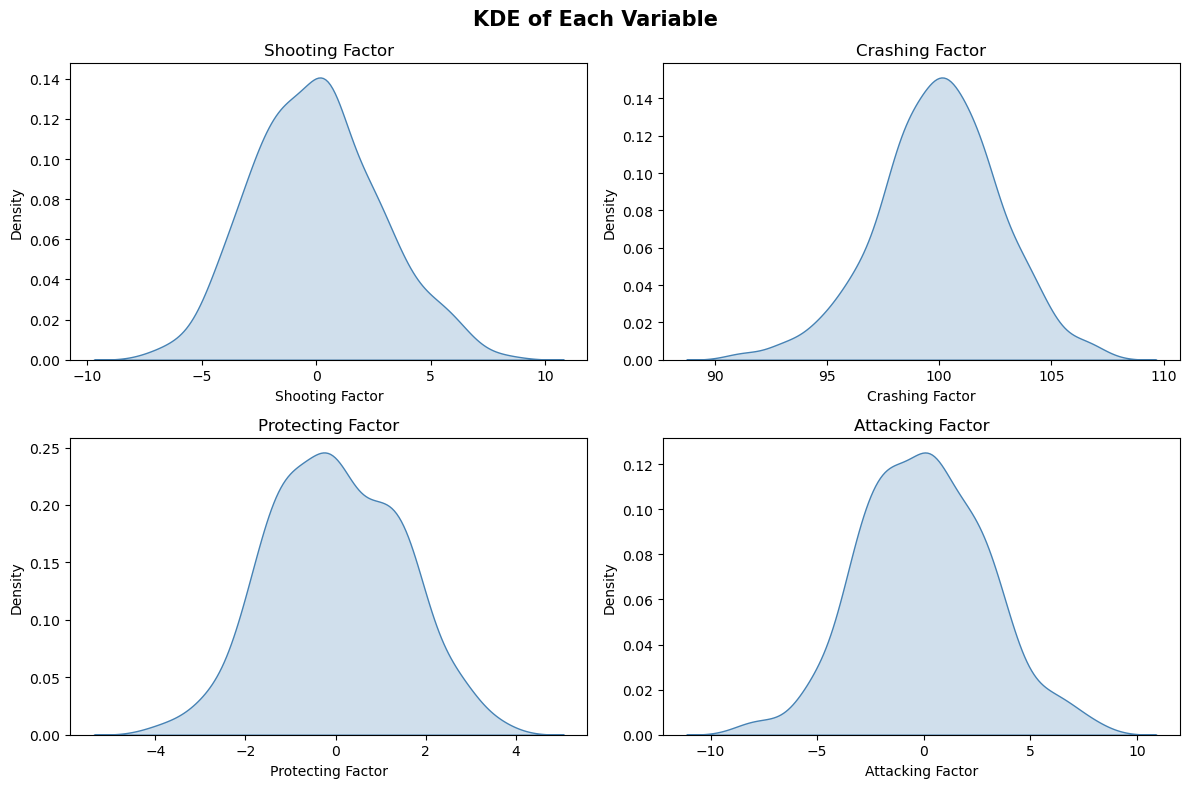

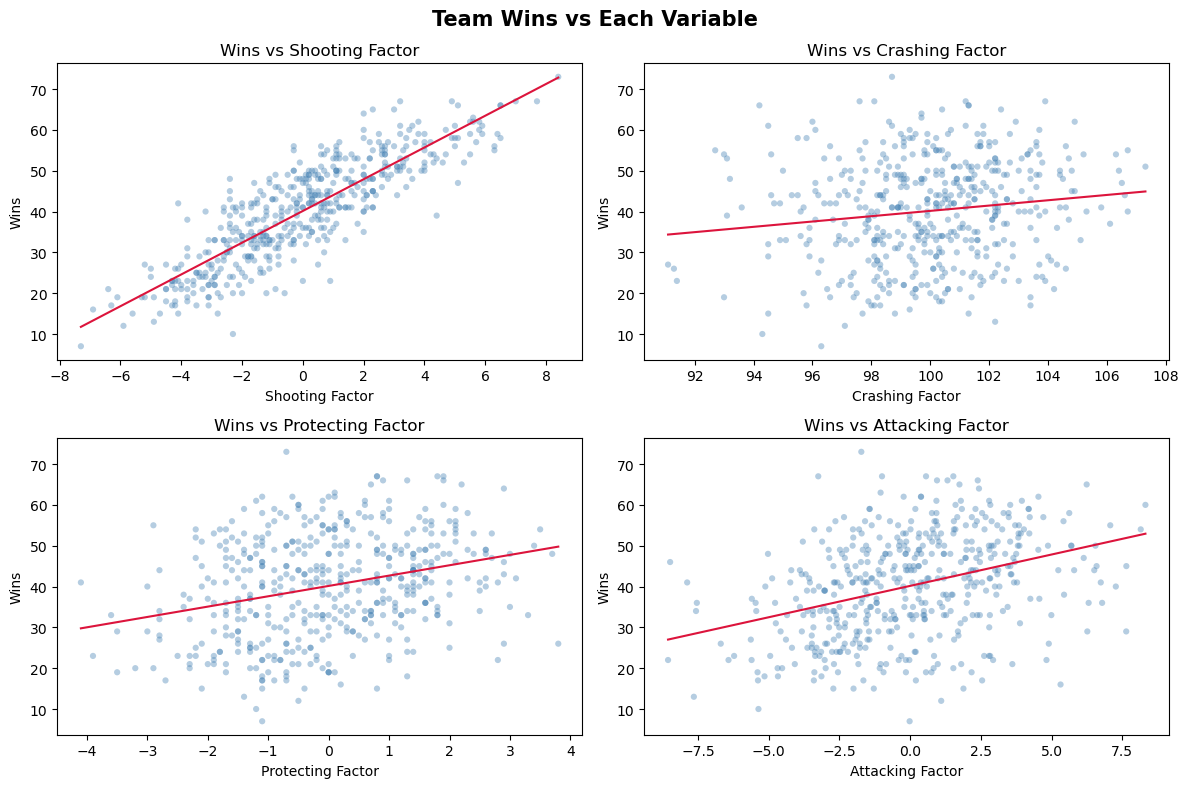


PAIRWISE CORRELATIONS (Pearson r)
  Shooting Factor & Crashing Factor: r = -0.0736
  Shooting Factor & Protecting Factor: r = 0.0602
  Shooting Factor & Attacking Factor: r = 0.2586
  Crashing Factor & Protecting Factor: r = -0.2907
  Crashing Factor & Attacking Factor: r = 0.0724
  Protecting Factor & Attacking Factor: r = -0.1378


In [13]:
#Question 1, Task 1

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

df = pd.read_csv("02_nba-four-factors.csv")

variables = ["Shooting Factor", "Crashing Factor", "Protecting Factor", "Attacking Factor"]
df["Protecting Factor"] = -1 * df["Protecting Factor"]

# Parameters for each variable
print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
for var in variables:
    s = df[var]
    print(f"\n{var}")
    print(f"  Max      : {s.max():.4f}")
    print(f"  Min      : {s.min():.4f}")
    print(f"  Mean     : {s.mean():.4f}")
    print(f"  Median   : {s.median():.4f}")
    print(f"  Variance : {s.var():.4f}")
    print(f"  Std Dev  : {s.std():.4f}")

# Kernel Density Estimation Plots for each variable 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("KDE of Each Variable", fontsize=15, fontweight="bold")

for ax, var in zip(axes.flatten(), variables):
    sns.kdeplot(df[var], ax=ax, fill=True, color="steelblue")
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

#Scatter plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Team Wins vs Each Variable", fontsize=15, fontweight="bold")

for ax, var in zip(axes.flatten(), variables):
    ax.scatter(df[var], df["W"], alpha=0.4, edgecolors="none", color="steelblue", s=20)
    m, b = np.polyfit(df[var], df["W"], 1)
    x_line = np.linspace(df[var].min(), df[var].max(), 200)
    ax.plot(x_line, m * x_line + b, color="crimson", linewidth=1.5)
    ax.set_title(f"Wins vs {var}")
    ax.set_xlabel(var)
    ax.set_ylabel("Wins")

plt.tight_layout()
plt.show()

# Intra-predictor correlations
print("\n" + "=" * 60)
print("PAIRWISE CORRELATIONS (Pearson r)")
print("=" * 60)
for v1, v2 in combinations(variables, 2):
    r = df[v1].corr(df[v2])
    print(f"  {v1} & {v2}: r = {r:.4f}")


#Preliminary thoughts on variables that are most predictive of win total
### Shooting factor looks the most predictive; the best fit line looks like it fits the data most tightly. 

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm

X = df[variables]
y = df["W"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("=" * 60)
print("MULTILINEAR REGRESSION: Wins ~ Four Factors")
print("=" * 60)
print(f"\nIntercept: {model.intercept_:.4f}")
print("\nCoefficients:")
for var, coef in zip(variables, model.coef_):
    print(f"  {var:<22}: {coef:.4f}")

print(f"\nR²  : {r2_score(y, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y, y_pred)):.4f}")


#Fitted Regression Equation (coefficients visible below)

#Interpreting each coefficient: Holding all other predictors constant, a one unit increase in shooting factor is associated with a 3.67 increase in wins

#Signs make sense!

#Attacking factor appears weakly associated with winning after adjusting for the presence of other variables; I don't think it's a coincidence that attacking factor is moderately correlated with shooting factor (the factor with the strongest effect on winning.)



MULTILINEAR REGRESSION: Wins ~ Four Factors

Intercept: -93.8449

Coefficients:
  Shooting Factor       : 3.6749
  Crashing Factor       : 1.3403
  Protecting Factor     : 3.0588
  Attacking Factor      : 0.7707

R²  : 0.9004
RMSE: 3.9567


In [17]:
#Task 3 Q1

# Standardizing and amending df
for var in variables:
    df[f"{var} (Standardized)"] = (df[var] - df[var].mean()) / df[var].std()

std_variables = [f"{var} (Standardized)" for var in variables]

# Multiple regression against standardized vars
X = df[std_variables]
y = df["W"]

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print("=" * 60)
print("MULTILINEAR REGRESSION: Wins ~ Standardized Four Factors")
print("=" * 60)
print(f"\nIntercept: {model.intercept_:.4f}")
print("\nCoefficients:")
for var, coef in zip(variables, model.coef_):
    print(f"  {var:<22}: {coef:.4f}")

print(f"\nR²  : {r2_score(y, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y, y_pred)):.4f}")

X_sm = sm.add_constant(X)
ols_model = sm.OLS(y, X_sm).fit()

conf_int = ols_model.conf_int(alpha=0.05)
conf_int.columns = ["CI Lower (2.5%)", "CI Upper (97.5%)"]

print("\n" + "=" * 60)
print("P-VALUES & 95% CONFIDENCE INTERVALS")
print("=" * 60)
for var in std_variables:
    p  = ols_model.pvalues[var]
    lo = conf_int.loc[var, "CI Lower (2.5%)"]
    hi = conf_int.loc[var, "CI Upper (97.5%)"]
    print(f"\n  {var}")
    print(f"    p-value : {p:.4f}")
    print(f"    95% CI  : [{lo:.4f}, {hi:.4f}]")

#By absolute value, in ascending order, Shooting Factor, Protecting, Crashing, Attacking 


#Which model is better for comparing the relative value of both factors: The standardized model; a one unit increase in factor A is not commensurable with a one unit increase in factor B because of the relative difficulties of moving up one unit might diverge between factors, while a one SD increase in A is probably more commensurable with a one SD increase in factor B.

# The fitted values are the same across both models. The span of the first 4 unstandardized column vectors is R^4, given linear independence.
# We know that the y-prediction that minimizes error is in this span, and so can be reached by some approp. lin combination of them.
# Linear independence is preserved by standardization. Hence, the span is unchanged; hence, the y-prediction that minimizes error can still
# be reached by the standardized column vectors (albeit after being multiplied by different coefficients.)



MULTILINEAR REGRESSION: Wins ~ Standardized Four Factors

Intercept: 40.1417

Coefficients:
  Shooting Factor       : 10.1345
  Crashing Factor       : 3.6405
  Protecting Factor     : 4.4408
  Attacking Factor      : 2.2866

R²  : 0.9004
RMSE: 3.9567

P-VALUES & 95% CONFIDENCE INTERVALS

  Shooting Factor (Standardized)
    p-value : 0.0000
    95% CI  : [9.7620, 10.5070]

  Crashing Factor (Standardized)
    p-value : 0.0000
    95% CI  : [3.2661, 4.0148]

  Protecting Factor (Standardized)
    p-value : 0.0000
    95% CI  : [4.0636, 4.8179]

  Attacking Factor (Standardized)
    p-value : 0.0000
    95% CI  : [1.9117, 2.6616]


In [29]:
#Task 4

import pandas as pd
import numpy as np
import statsmodels.api as sm

# Computing RSE
n = len(y)
p = len(std_variables)
RSS = np.sum((y - ols_model.fittedvalues) ** 2)
RSE = np.sqrt(RSS / (n - (p + 1)))

print("=" * 60)
print("RESIDUAL STANDARD ERROR")
print("=" * 60)
print(f"  RSS : {RSS:.4f}")
print(f"  n   : {n}")
print(f"  p+1 : {p + 1}")
print(f"  RSE : {RSE:.4f}")

# Reporting SE for each coefficient and confidence interval
print("\n" + "=" * 60)
print("P-VALUES & 95% CONFIDENCE INTERVALS")
print("=" * 60)
for var in std_variables:
    p  = ols_model.pvalues[var]
    lo = conf_int.loc[var, "CI Lower (2.5%)"]
    hi = conf_int.loc[var, "CI Upper (97.5%)"]
    print(f"\n  {var}")
    print(f"    p-value : {p:.4f}")
    print(f"    95% CI  : [{lo:.4f}, {hi:.4f}]")

#It seems like we can reject the null hypothesis (i.e. coefficient = 0) with 95% certainty for all coefficients.

X = sm.add_constant(df[std_variables])
y = df["W"]

model = sm.OLS(y, X).fit()

lakers = df[(df["TEAM"] == "Los Angeles Lakers") & (df["Season End"] == 2008)]

print("2008 Los Angeles Lakers — Raw Variable Values")
print("=" * 60)
print(lakers[["TEAM", "Season End", "W"] + variables].to_string(index=False))

lakers_X = sm.add_constant(lakers[std_variables], has_constant="add")

# Point prediction for 2008 lakers
point_pred = model.predict(lakers_X).values[0]
print(f"\n(1) Point Prediction for Wins : {point_pred:.4f}")

#95% CI
pred_summary = model.get_prediction(lakers_X).summary_frame(alpha=0.05)
ci_lo = pred_summary["mean_ci_lower"].values[0]
ci_hi = pred_summary["mean_ci_upper"].values[0]
print(f"\n(2) 95% Confidence Interval   : [{ci_lo:.4f}, {ci_hi:.4f}]")

# 95% Prediction Interval
pi_lo = pred_summary["obs_ci_lower"].values[0]
pi_hi = pred_summary["obs_ci_upper"].values[0]
print(f"\n(3) 95% Prediction Interval   : [{pi_lo:.4f}, {pi_hi:.4f}]")

#The prediction interval should be larger than the confidence interval. This is because the prediction interval accounts for uncertainty in the error estimate. 


RESIDUAL STANDARD ERROR
  RSS : 7514.6451
  n   : 480
  p+1 : 5
  RSE : 3.9775

P-VALUES & 95% CONFIDENCE INTERVALS

  Shooting Factor (Standardized)
    p-value : 0.0000
    95% CI  : [6.3414, 13.9276]

  Crashing Factor (Standardized)
    p-value : 0.0000
    95% CI  : [-0.1720, 7.4529]

  Protecting Factor (Standardized)
    p-value : 0.0000
    95% CI  : [0.6000, 8.2815]

  Attacking Factor (Standardized)
    p-value : 0.0000
    95% CI  : [-1.5317, 6.1050]
2008 Los Angeles Lakers — Raw Variable Values
              TEAM  Season End  W  Shooting Factor  Crashing Factor  Protecting Factor  Attacking Factor
Los Angeles Lakers        2008 57              4.0             99.9                0.2          4.230178

(1) Point Prediction for Wins : 58.6243

(2) 95% Confidence Interval   : [57.8799, 59.3686]

(3) 95% Prediction Interval   : [50.7733, 66.4752]


In [32]:
#Q1 Task 5

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ── Train/test split ──────────────────────────────────────────────────────────
train, test = train_test_split(df, test_size=0.3, random_state=42)

y_train = train["W"]
y_test  = test["W"]

# ── Model 1: Unstandardized ───────────────────────────────────────────────────
X_train_raw = sm.add_constant(train[variables])
X_test_raw  = sm.add_constant(test[variables], has_constant="add")

model_raw  = sm.OLS(y_train, X_train_raw).fit()
y_pred_raw = model_raw.predict(X_test_raw)
rmse_raw   = np.sqrt(mean_squared_error(y_test, y_pred_raw))

# ── Model 2: Standardized ─────────────────────────────────────────────────────
X_train_std = sm.add_constant(train[std_variables])
X_test_std  = sm.add_constant(test[std_variables], has_constant="add")

model_std  = sm.OLS(y_train, X_train_std).fit()
y_pred_std = model_std.predict(X_test_std)
rmse_std   = np.sqrt(mean_squared_error(y_test, y_pred_std))

# ── Results ───────────────────────────────────────────────────────────────────
print("=" * 60)
print("TRAIN/TEST SPLIT: 70% / 30%")
print(f"  Training observations : {len(train)}")
print(f"  Test observations     : {len(test)}")

print("\n" + "=" * 60)
print("TEST-SET RMSE")
print("=" * 60)
print(f"  Model 1 (Unstandardized) : {rmse_raw:.4f}")
print(f"  Model 2 (Standardized)   : {rmse_std:.4f}")


#The models have identical RMSE on the test data. This is because they are functionally the same model - the coefficients for 
#the standardized model are multiplied by the SD to offset the fact that each of the covariates was divided by them. Thus, they produce
#the same RSME when tested on the same data. 

TRAIN/TEST SPLIT: 70% / 30%
  Training observations : 336
  Test observations     : 144

TEST-SET RMSE
  Model 1 (Unstandardized) : 4.1364
  Model 2 (Standardized)   : 4.1364


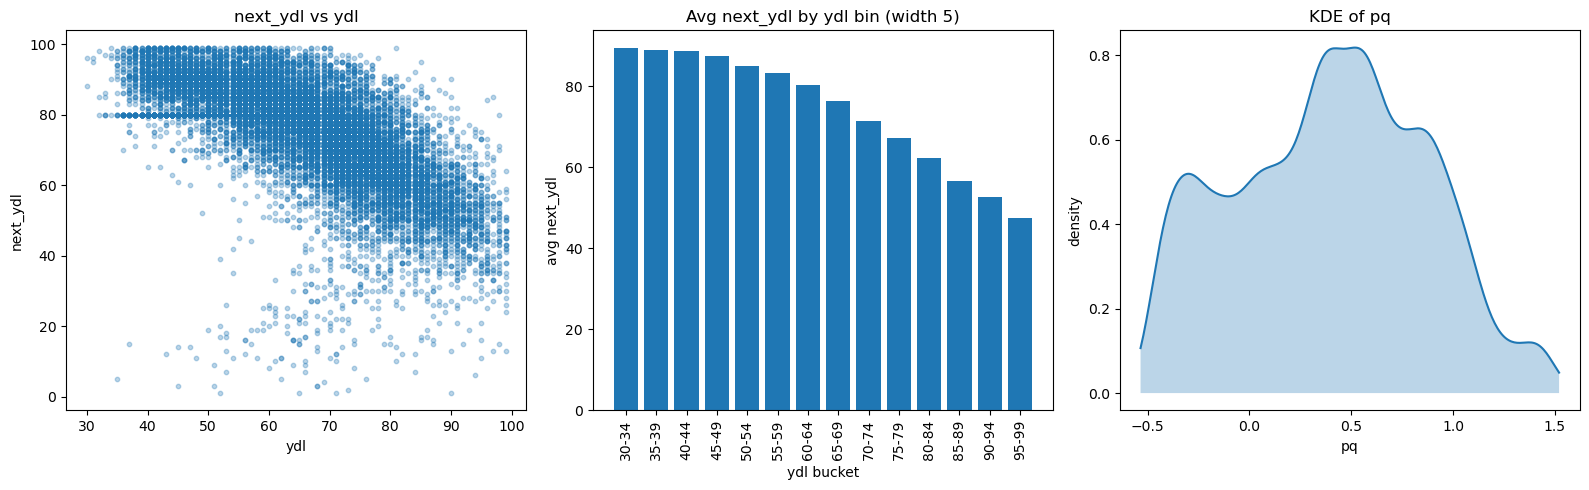

In [33]:
#Q2 Task 1

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

df = pd.read_csv("02_punts.csv")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (1) Scatter: next_ydl vs ydl
axes[0].scatter(df["ydl"], df["next_ydl"], alpha=0.3, s=10)
axes[0].set_xlabel("ydl")
axes[0].set_ylabel("next_ydl")
axes[0].set_title("next_ydl vs ydl")

# (2) Binned average of next_ydl by ydl bucket (width 5)
bins = np.arange(0, df["ydl"].max() + 5, 5)
labels = [f"{b}-{b+4}" for b in bins[:-1]]
df["ydl_bin"] = pd.cut(df["ydl"], bins=bins, right=False, labels=labels)
bin_means = df.groupby("ydl_bin", observed=True)["next_ydl"].mean()

axes[1].bar(range(len(bin_means)), bin_means.values, tick_label=bin_means.index)
axes[1].set_xlabel("ydl bucket")
axes[1].set_ylabel("avg next_ydl")
axes[1].set_title("Avg next_ydl by ydl bin (width 5)")
axes[1].tick_params(axis="x", rotation=90)

# (3) KDE of pq
pq = df["pq"].dropna()
kde = gaussian_kde(pq)
x = np.linspace(pq.min(), pq.max(), 300)
axes[2].plot(x, kde(x))
axes[2].fill_between(x, kde(x), alpha=0.3)
axes[2].set_xlabel("pq")
axes[2].set_ylabel("density")
axes[2].set_title("KDE of pq")

plt.tight_layout()
plt.show()

#The relationship between next_ydl and ydl does not look linear. The rate of decline seems to increase around ~~50 yds, implying non-linearity.
#Thus, when my starting ydl goes from 30 to 50, I see only modest declines in next_ydl; these declines increase from 50 yds onwards.

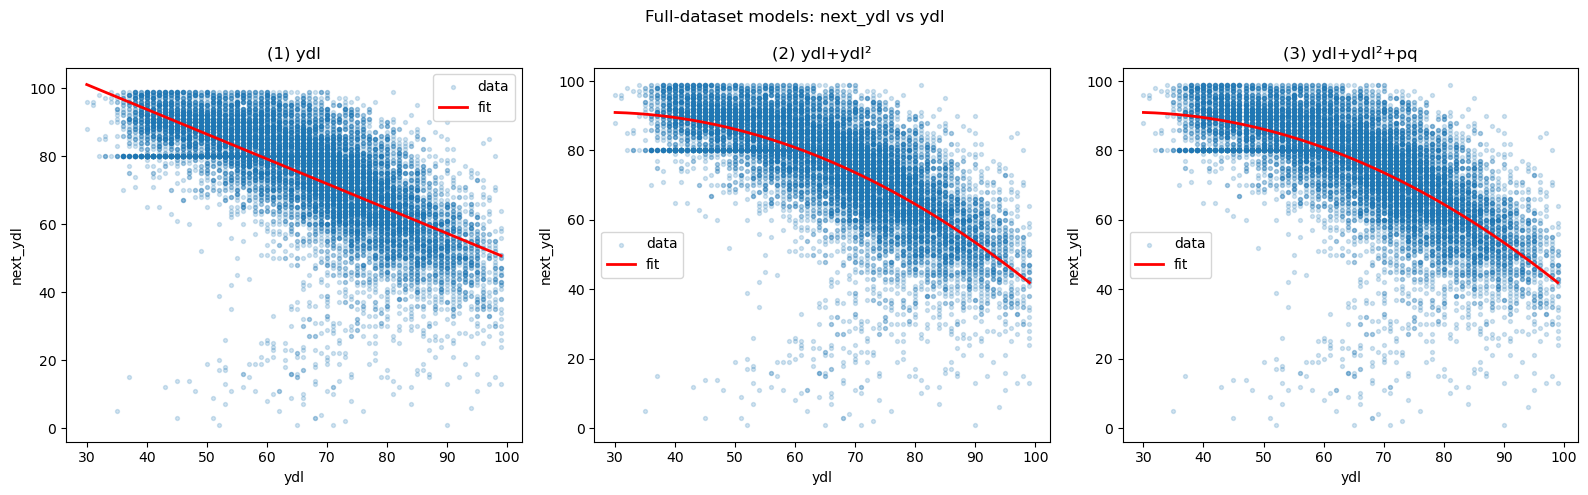


--- RMSE on test set (70/30 split) ---
  (1) ydl: RMSE = 11.1050
  (2) ydl+ydl²: RMSE = 10.9533
  (3) ydl+ydl²+pq: RMSE = 10.9410


In [34]:
#Q2 task 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

df["ydl2"] = df["ydl"] ** 2

X1 = df[["ydl"]]
X2 = df[["ydl", "ydl2"]]
X3 = df[["ydl", "ydl2", "pq"]]
y  = df["next_ydl"]

# --- Full-dataset models ---
models_full = {}
for name, X in [("(1) ydl", X1), ("(2) ydl+ydl²", X2), ("(3) ydl+ydl²+pq", X3)]:
    m = LinearRegression().fit(X, y)
    models_full[name] = m

# --- Plots for full-dataset models ---
ydl_range = np.linspace(df["ydl"].min(), df["ydl"].max(), 300)
pq_mean   = df["pq"].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Full-dataset models: next_ydl vs ydl")

for ax, (name, X) in zip(axes, [("(1) ydl", X1), ("(2) ydl+ydl²", X2), ("(3) ydl+ydl²+pq", X3)]):
    ax.scatter(df["ydl"], y, alpha=0.2, s=8, label="data")
    m = models_full[name]
    if name == "(1) ydl":
        X_line = pd.DataFrame({"ydl": ydl_range})
    elif name == "(2) ydl+ydl²":
        X_line = pd.DataFrame({"ydl": ydl_range, "ydl2": ydl_range**2})
    else:
        X_line = pd.DataFrame({"ydl": ydl_range, "ydl2": ydl_range**2, "pq": pq_mean})
    ax.plot(ydl_range, m.predict(X_line), color="red", linewidth=2, label="fit")
    ax.set_title(name)
    ax.set_xlabel("ydl")
    ax.set_ylabel("next_ydl")
    ax.legend()

plt.tight_layout()
plt.show()

# --- Train/test split ---
X1_tr, X1_te, X2_tr, X2_te, X3_tr, X3_te, y_tr, y_te = [None]*8

X1_tr, X1_te, y_tr, y_te = train_test_split(X1, y, test_size=0.3, random_state=42)
X2_tr, X2_te = train_test_split(X2, test_size=0.3, random_state=42)[:2]  # same split via index

# Re-do cleanly with a shared index split
idx_tr, idx_te = train_test_split(df.index, test_size=0.3, random_state=42)

print("\n--- RMSE on test set (70/30 split) ---")
for name, X in [("(1) ydl", X1), ("(2) ydl+ydl²", X2), ("(3) ydl+ydl²+pq", X3)]:
    m = LinearRegression().fit(X.loc[idx_tr], y.loc[idx_tr])
    preds = m.predict(X.loc[idx_te])
    rmse  = np.sqrt(mean_squared_error(y.loc[idx_te], preds))
    print(f"  {name}: RMSE = {rmse:.4f}")

#Trade-off between linear and quadratic models: Quadratic models have better fit, but are harder to interpret. 

#Adding punter quality seems to marginally improve RMSE. The coefficient on punter quality tells us that for every one unit
#increase in pq, there is a 1.3yd increase in next_ydl.

#Going forward, I will select the model without pq (so model (2)). This is because the marginal drop in RMSE does not justify the drop 
#in flexibility from adding pq.

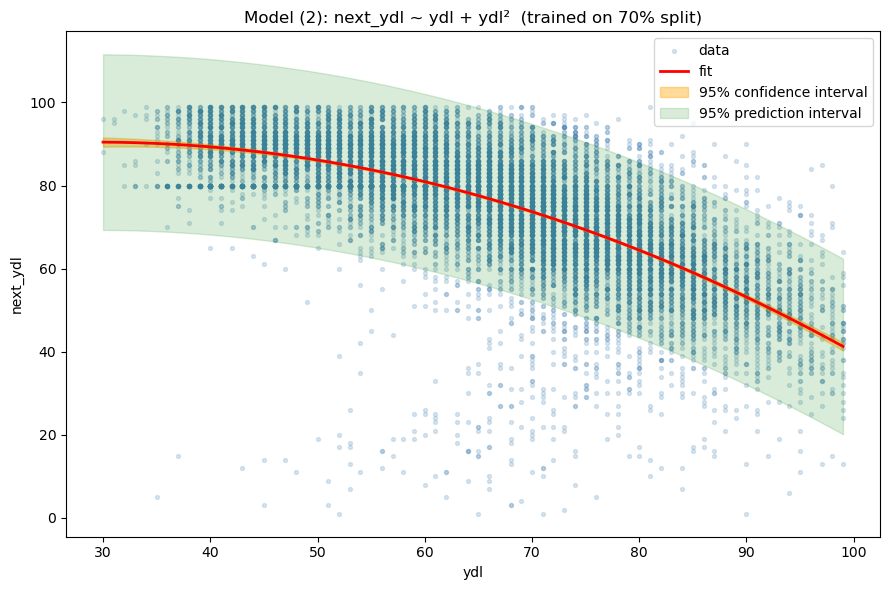

In [35]:
#Q2, T3

X = df[["ydl", "ydl2"]]
y = df["next_ydl"]

idx_tr, idx_te = train_test_split(df.index, test_size=0.3, random_state=42)

X_tr = sm.add_constant(X.loc[idx_tr])
model = sm.OLS(y.loc[idx_tr], X_tr).fit()

# Prediction grid
ydl_range = np.linspace(df["ydl"].min(), df["ydl"].max(), 300)
X_line = sm.add_constant(pd.DataFrame({"ydl": ydl_range, "ydl2": ydl_range**2}))

pred = model.get_prediction(X_line)
summary = pred.summary_frame(alpha=0.05)  # 95%

plt.figure(figsize=(9, 6))
plt.scatter(df["ydl"], y, alpha=0.2, s=8, color="steelblue", label="data")
plt.plot(ydl_range, summary["mean"], color="red", linewidth=2, label="fit")
plt.fill_between(ydl_range, summary["mean_ci_lower"], summary["mean_ci_upper"],
                 alpha=0.4, color="orange", label="95% confidence interval")
plt.fill_between(ydl_range, summary["obs_ci_lower"], summary["obs_ci_upper"],
                 alpha=0.15, color="green", label="95% prediction interval")
plt.xlabel("ydl")
plt.ylabel("next_ydl")
plt.title("Model (2): next_ydl ~ ydl + ydl²  (trained on 70% split)")
plt.legend()
plt.tight_layout()
plt.show()

#The confidence interval is much narrower than the prediction interval because the latter has to account for uncertainty in the error estimation.

#Uncertainty seems to be larger at the tails - my guess is that this is because fewer punts are taken at the extreme values, so a smaller sample size inflates uncertainty.

Top 5 punters by PYOE:
          punter  avg_PYOE  n_punts   se_PYOE
B.Roethlisberger 18.700797        1       NaN
         A.Rosas 16.497318        3  3.826929
     C.Catanzaro 13.093365        2 11.926601
   S.Weatherford 11.820403        4  2.715674
         N.Novak 10.010633        1       NaN


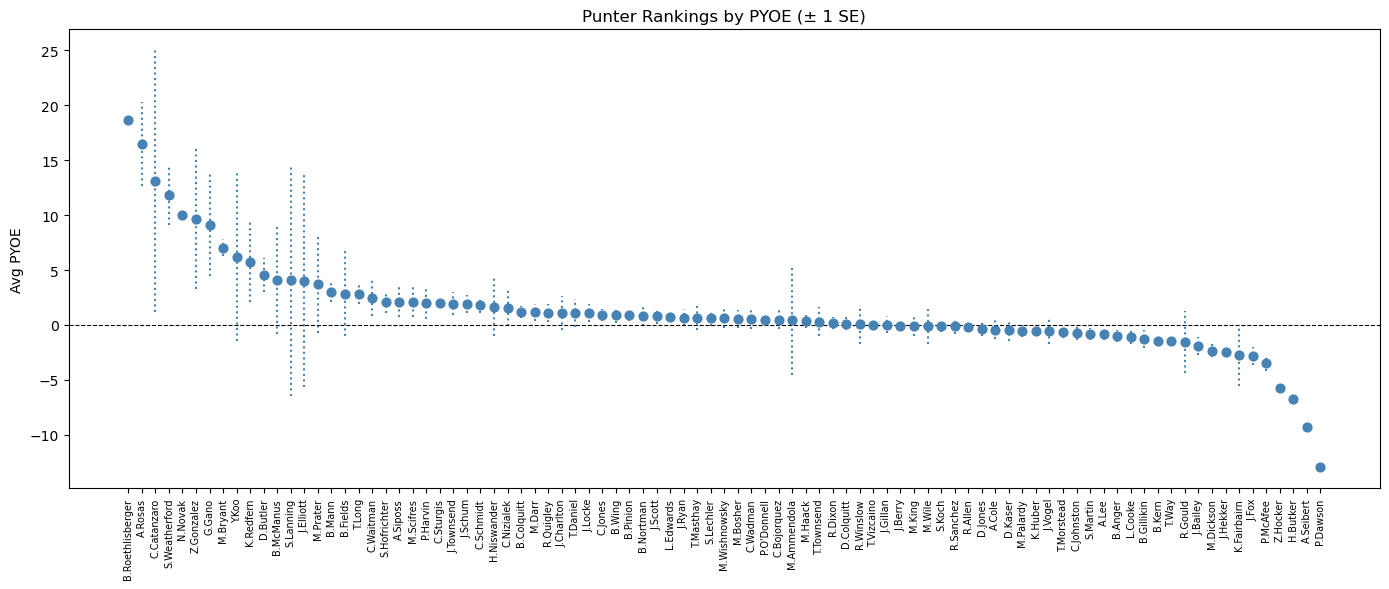

In [36]:
#Q2 Task 4

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import statsmodels.api as sm


# Predict for every row and compute PYOE
X_all = sm.add_constant(X, has_constant="add")
df["predicted"] = model.predict(X_all)
df["PYOE"] = df["predicted"] - df["next_ydl"]

# Per-punter summary
punter_stats = (
    df.groupby("punter")["PYOE"]
    .agg(
        avg_PYOE="mean",
        n_punts="count",
        se_PYOE=lambda x: x.std() / np.sqrt(len(x))
    )
    .sort_values("avg_PYOE", ascending=False)
    .reset_index()
)

print("Top 5 punters by PYOE:")
print(punter_stats.head(5).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

x_pos = np.arange(len(punter_stats))
ax.scatter(x_pos, punter_stats["avg_PYOE"], color="steelblue", zorder=3, s=40)

for i, row in punter_stats.iterrows():
    ax.plot([i, i], [row["avg_PYOE"] - row["se_PYOE"], row["avg_PYOE"] + row["se_PYOE"]],
            color="steelblue", linestyle="dotted", linewidth=1.5)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x_pos)
ax.set_xticklabels(punter_stats["punter"], rotation=90, fontsize=7)
ax.set_ylabel("Avg PYOE")
ax.set_title("Punter Rankings by PYOE (± 1 SE)")
plt.tight_layout()
plt.show()


#Gano, Redfern and Mann are clearly above average punters, given the low SE and high ranking. The average punt is 0.021, so anyone above this value 
# with an SE below 3 is probably a reliably above average punter.